<a href="https://colab.research.google.com/github/jhongarciaalcaraz961-droid/-Phase_4_-203018207_1_Jhon_Garcia/blob/main/Predictive_HVAC_(Heating%2C_Ventilation%2C_and_Air_Conditioning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 4 - Solution Implementation and Descriptive Analysis

**Student**

                         Jhon Jairo Garcia Alcaraz

                            Group: 203018207_1

**Instructor**

                       Maria Alejandra Varona Taborda

**Course**

                      (203018207A_2202) – Data Analytics

                Universidad Nacional Abierta y a Distancia UNAD

                   Specialization in Telecommunications Networks

                                 July 2026

# Context
This dataset is collected from 255 sensor time series, instrumented in 51 rooms in 4 floors of the Sutardja Dai Hall(SDH) at UC Berkeley. It can be used to investigate patterns in physical properties of a room in a building. Moreover, it can also be used for experiments relating to Internet-of-Things (IoT), sensor fusion network or time-series tasks. This dataset is suitable for both supervised (classification and regression) and unsupervised learning (clustering) tasks.

# Content
Each room includes 5 types of measurements: CO2 concentration, room air humidity, room temperature, luminosity, and PIR motion sensor data, collected over a period of one week from Friday, August 23, 2013 to Saturday, August 31, 2013. The PIR motion sensor is sampled once every 10 seconds and the remaining sensors are sampled once every 5 seconds. Each file contains the timestamps (in Unix Epoch Time) and actual readings from the sensor.

The passive infrared sensor (PIR sensor) is an electronic sensor that measures infrared (IR) light radiating from objects in its field of view, which measures the occupancy in a room. Approximately 6% of the PIR data is non-zero, indicating an occupied status of the room. The remaining 94% of the PIR data is zero, indicating an empty room.

# Predictive HVAC (Heating, Ventilation, and Air Conditioning)


1. Import Library

2. Data Preparation

3. Data division

4. Model Learning

5. Model Evaluation

6. Save the model

# 1. Import Library

In [ ]:
# ==============================================================================
# PIPELINE DE MACHINE LEARNING PARA DATOS MULTI-SENSOR
# ==============================================================================

# --- IMPORTACIÓN DE LIBRERÍAS CRÍTICAS ---
import os                          # Para interactuar con el sistema de archivos y rutas
import warnings
import zipfile                     # Para descomprimir la carpeta de datos en Colab
import pandas as pd                # Para la manipulación y análisis de datos estructurales
import numpy as np                 # Para operaciones matemáticas avanzadas
import matplotlib.pyplot as plt    # Para la generación de gráficos y visualizaciones
from sklearn.model_selection import train_test_split # Para dividir el dataset
from sklearn.ensemble import RandomForestRegressor   # El algoritmo de Machine Learning (Modelo)
from sklearn.metrics import mean_squared_error, r2_score # Métricas de evaluación de regresión

# Configuraciones de advertencias y formato que definiste
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)



# 2. Data Preparation

In [ ]:
print("--- Iniciando Fase 1: Exploración y Unificación en Colab ---")

ruta_colab = './datos_sensores'

lista_dataframes = []

# Tu bucle de exploración os.walk adaptado para listar y cargar en Colab
for dirname, _, filenames in os.walk(ruta_colab):
    for filename in filenames:
        if filename.lower().endswith('.csv'):
            ruta_completa = os.path.join(dirname, filename)
            # Esto imprimirá la ubicación exacta de cada archivo de sensor en Colab
            print(f"Archivo detectado y cargando: {ruta_completa}")



--- Iniciando Fase 1: Exploración y Unificación en Colab ---
Archivo detectado y cargando: ./datos_sensores/sensores_data/454/temperature.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/454/pir.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/454/co2.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/454/light.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/454/humidity.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/666/temperature.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/666/pir.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/666/co2.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/666/light.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/666/humidity.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/456/temperature.csv
Archivo detectado y cargando: ./datos_sensores/sensores_data/456/pir.csv
Archivo detectado y carga

In [ ]:
df = pd.DataFrame()


for dirname, _, filenames in os.walk('./datos_sensores'):

    if len(filenames) > 1:

        room_df = pd.DataFrame()

        room_id = dirname.split('/')[-1]

        print('Room ID: ', room_id)

        for i, filename in enumerate(filenames):

#             print(filename)

            feat_name = filename.split('.')[0]
            tmp_df = pd.read_csv(os.path.join(dirname, filename), names=[feat_name], header=0)

            if i == 0:
                room_df = tmp_df

            else:

                room_df = pd.concat([room_df, tmp_df], axis=1, join="outer")

        room_df['room_ID'] = [room_id]*room_df.shape[0]

        df = pd.concat([df, room_df], axis=0)

Room ID:  454
Room ID:  666
Room ID:  456
Room ID:  510
Room ID:  452
Room ID:  413
Room ID:  640
Room ID:  752
Room ID:  458
Room ID:  442
Room ID:  776
Room ID:  513
Room ID:  448
Room ID:  648
Room ID:  656B
Room ID:  734
Room ID:  722
Room ID:  415
Room ID:  724
Room ID:  754
Room ID:  552
Room ID:  446
Room ID:  621A
Room ID:  656A
Room ID:  719
Room ID:  746
Room ID:  462
Room ID:  554
Room ID:  668
Room ID:  558
Room ID:  644
Room ID:  556
Room ID:  424
Room ID:  417
Room ID:  421
Room ID:  422
Room ID:  621D
Room ID:  511
Room ID:  726
Room ID:  621C
Room ID:  419
Room ID:  721
Room ID:  562
Room ID:  621
Room ID:  423
Room ID:  723
Room ID:  621E
Room ID:  664
Room ID:  717
Room ID:  748
Room ID:  564


In [ ]:
# Usando len() para las filas si prefieres un formato personalizado
print("Shape: ", (len(df), len(df.columns)))

Shape:  (14381528, 6)


In [ ]:
df.head()

,temperature,pir,co2,light,humidity,room_ID
1377299122,23.50,NaN,NaN,3.00,51.35,454
1377299127,23.51,0.00,364.00,4.00,51.35,454
1377299130,23.50,0.00,368.00,3.00,51.35,454
1377299132,23.50,NaN,NaN,4.00,51.35,454
1377299137,23.50,NaN,NaN,4.00,51.35,454


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14381528 entries, 1377299122 to 1377970485
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   temperature  float64
 1   pir          float64
 2   co2          float64
 3   light        float64
 4   humidity     float64
 5   room_ID      object 
dtypes: float64(5), object(1)
memory usage: 768.1+ MB


In [ ]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)

    print("\n##################### Types #####################")
    print(dataframe.dtypes)

    print("\n##################### Head #####################")
    print(dataframe.head(head))

    print("\n##################### Tail #####################")
    print(dataframe.tail(head))

    print("\n##################### NA (Valores Nulos) #####################")
    print(dataframe.isnull().sum())

    print("\n##################### Quantiles (Solo Numéricos) #####################")
    # CORRECCIÓN CRÍTICA: Usamos numeric_only=True para evitar errores con columnas de texto (como room_ID)
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1], numeric_only=True).T)

# Ejecuta la función sobre tu DataFrame
check_df(df)

##################### Shape #####################
(14381528, 6)

##################### Types #####################
temperature    float64
pir            float64
co2            float64
light          float64
humidity       float64
room_ID         object
dtype: object

##################### Head #####################
            temperature  pir    co2  light  humidity room_ID
1377299122        23.50  NaN    NaN   3.00     51.35     454
1377299127        23.51 0.00 364.00   4.00     51.35     454
1377299130        23.50 0.00 368.00   3.00     51.35     454
1377299132        23.50  NaN    NaN   4.00     51.35     454
1377299137        23.50  NaN    NaN   4.00     51.35     454

##################### Tail #####################
            temperature  pir  co2  light  humidity room_ID
1377917532          NaN  NaN  NaN   5.00       NaN     564
1377917557          NaN  NaN  NaN   4.00       NaN     564
1377917782          NaN  NaN  NaN   4.00     56.48     564
1377917812          NaN  NaN  N

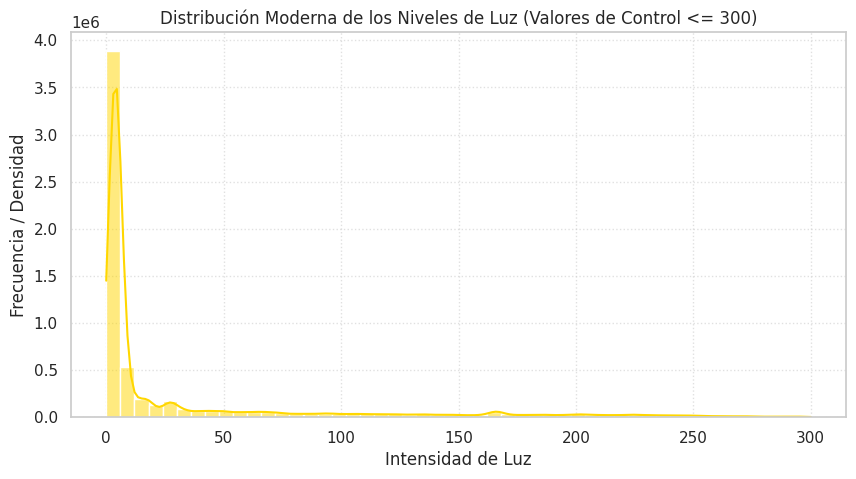

In [ ]:
# Filtramos visualmente para ver la distribución real de la luz ambiental
df_luz_normal = df[df['light'] <= 300]

plt.figure(figsize=(10, 5))
# kde=True añade la línea de densidad curva que tenía distplot
sns.histplot(df_luz_normal['light'], kde=True, color='gold', bins=50)
plt.title('Distribución Moderna de los Niveles de Luz (Valores de Control <= 300)')
plt.xlabel('Intensidad de Luz')
plt.ylabel('Frecuencia / Densidad')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
